# Commercial Subtype Classification

This notebook trains and evaluates a multiclass model for assigning Level-2 commercial building subtypes. It performs feature selection, hyperparameter optimization, class-imbalance handling, and final model evaluation.

**Input**
- Preprocessed commercial-subtype training, validation, and test data.
- Candidate machine-learning features.

**Output**
- Selected features for commercial subtype classification.
- Optimized multiclass models and evaluation results.
- Final trained commercial subtype classifier.

In [1]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train 
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l3a_comm_subtypes'

print(f"Training level: {LEVEL}")

Training level: l3a_comm_subtypes


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_raw.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_raw.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_raw.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
candidate_features = joblib.load(os.path.join(ML_DIR, 'candidate_features.pkl'))



print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
n_classes = len(np.unique(y_train))

# print class count for training, test and validation sets
print("\nClass distribution in training set:")
print(np.bincount(y_train))
print("\nClass distribution in validation set:")
print(np.bincount(y_val))
print("\nClass distribution in test set:")
print(np.bincount(y_test))
print(f"Classes             : {classes}")

print(f"CV Training Pool    : {X_train.shape[0]:,} rows")
print(f"Early Stop Monitor  : {X_val.shape[0]:,} rows (X_val)")
print(f"Holdout Test Set    : {X_test.shape[0]:,} rows (X_test)")


X_train : (224171, 110)
X_val   : (13166, 110)
X_test  : (26205, 110)

Class distribution in training set:
[ 26012  27680  47026 123453]

Class distribution in validation set:
[1581 1639 2694 7252]

Class distribution in test set:
[ 3029  3315  5366 14495]
Classes             : ['accommodation' 'food_drink' 'office' 'retail']
CV Training Pool    : 224,171 rows
Early Stop Monitor  : 13,166 rows (X_val)
Holdout Test Set    : 26,205 rows (X_test)


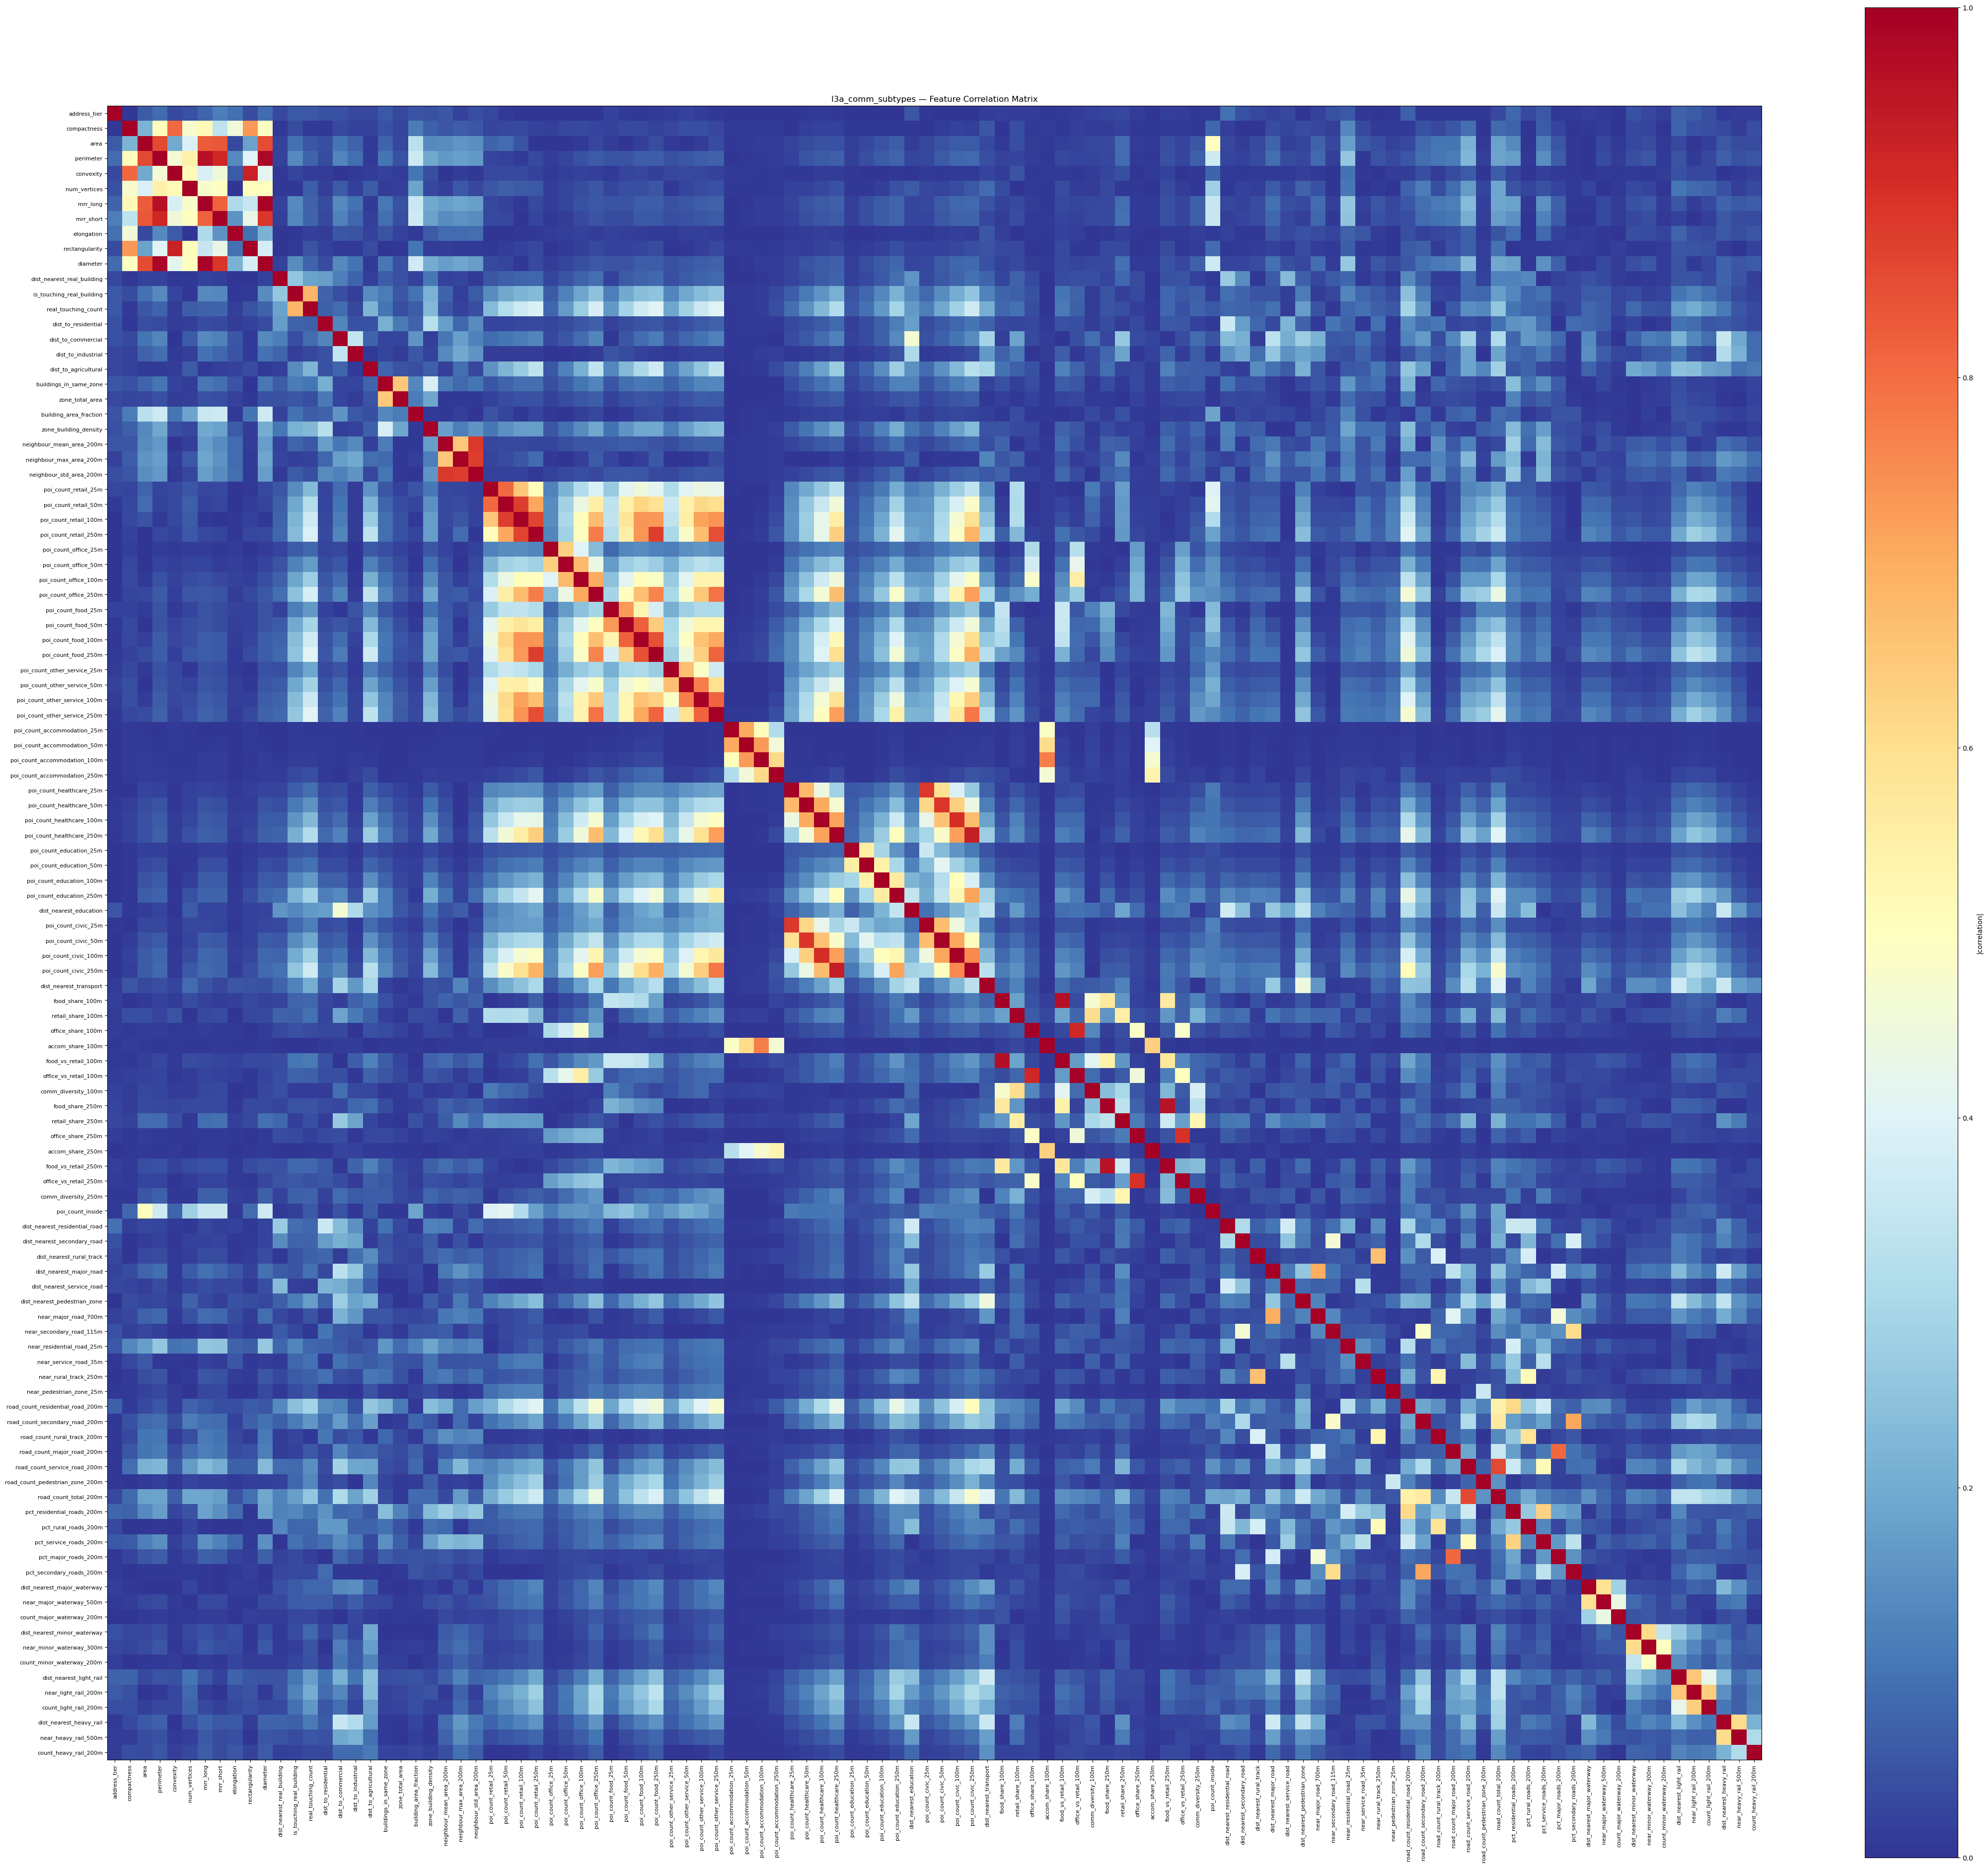

In [3]:
# Correlation Heatmap

corr_matrix = X_train[candidate_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(candidate_features)*0.4), max(6, len(candidate_features)*0.35)))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))
ax.set_xticklabels(candidate_features, rotation=90, fontsize=8)
ax.set_yticklabels(candidate_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Feature Correlation Matrix')
plt.tight_layout()
plt.show()


Class labels and their corresponding class names:
Class 0: accommodation
Class 1: food_drink
Class 2: office
Class 3: retail
Excluded features (correlation <= 0.7 with all other features):
['address_tier', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_other_service_25m', 'poi_count_accommodation_250m', 'poi_count_education_25m', 'poi_count_education_50m', 'poi_count_education_100m', 'dist_nearest_education', 'dist_nearest_transport', 'retail_share_100m', 'comm_diversity_100m', 'retail_share_250m', 'accom_share_250m', 'comm_diversity_250m', 'poi_count_inside', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_rural_track', 'dist_nearest_major_road', 'd

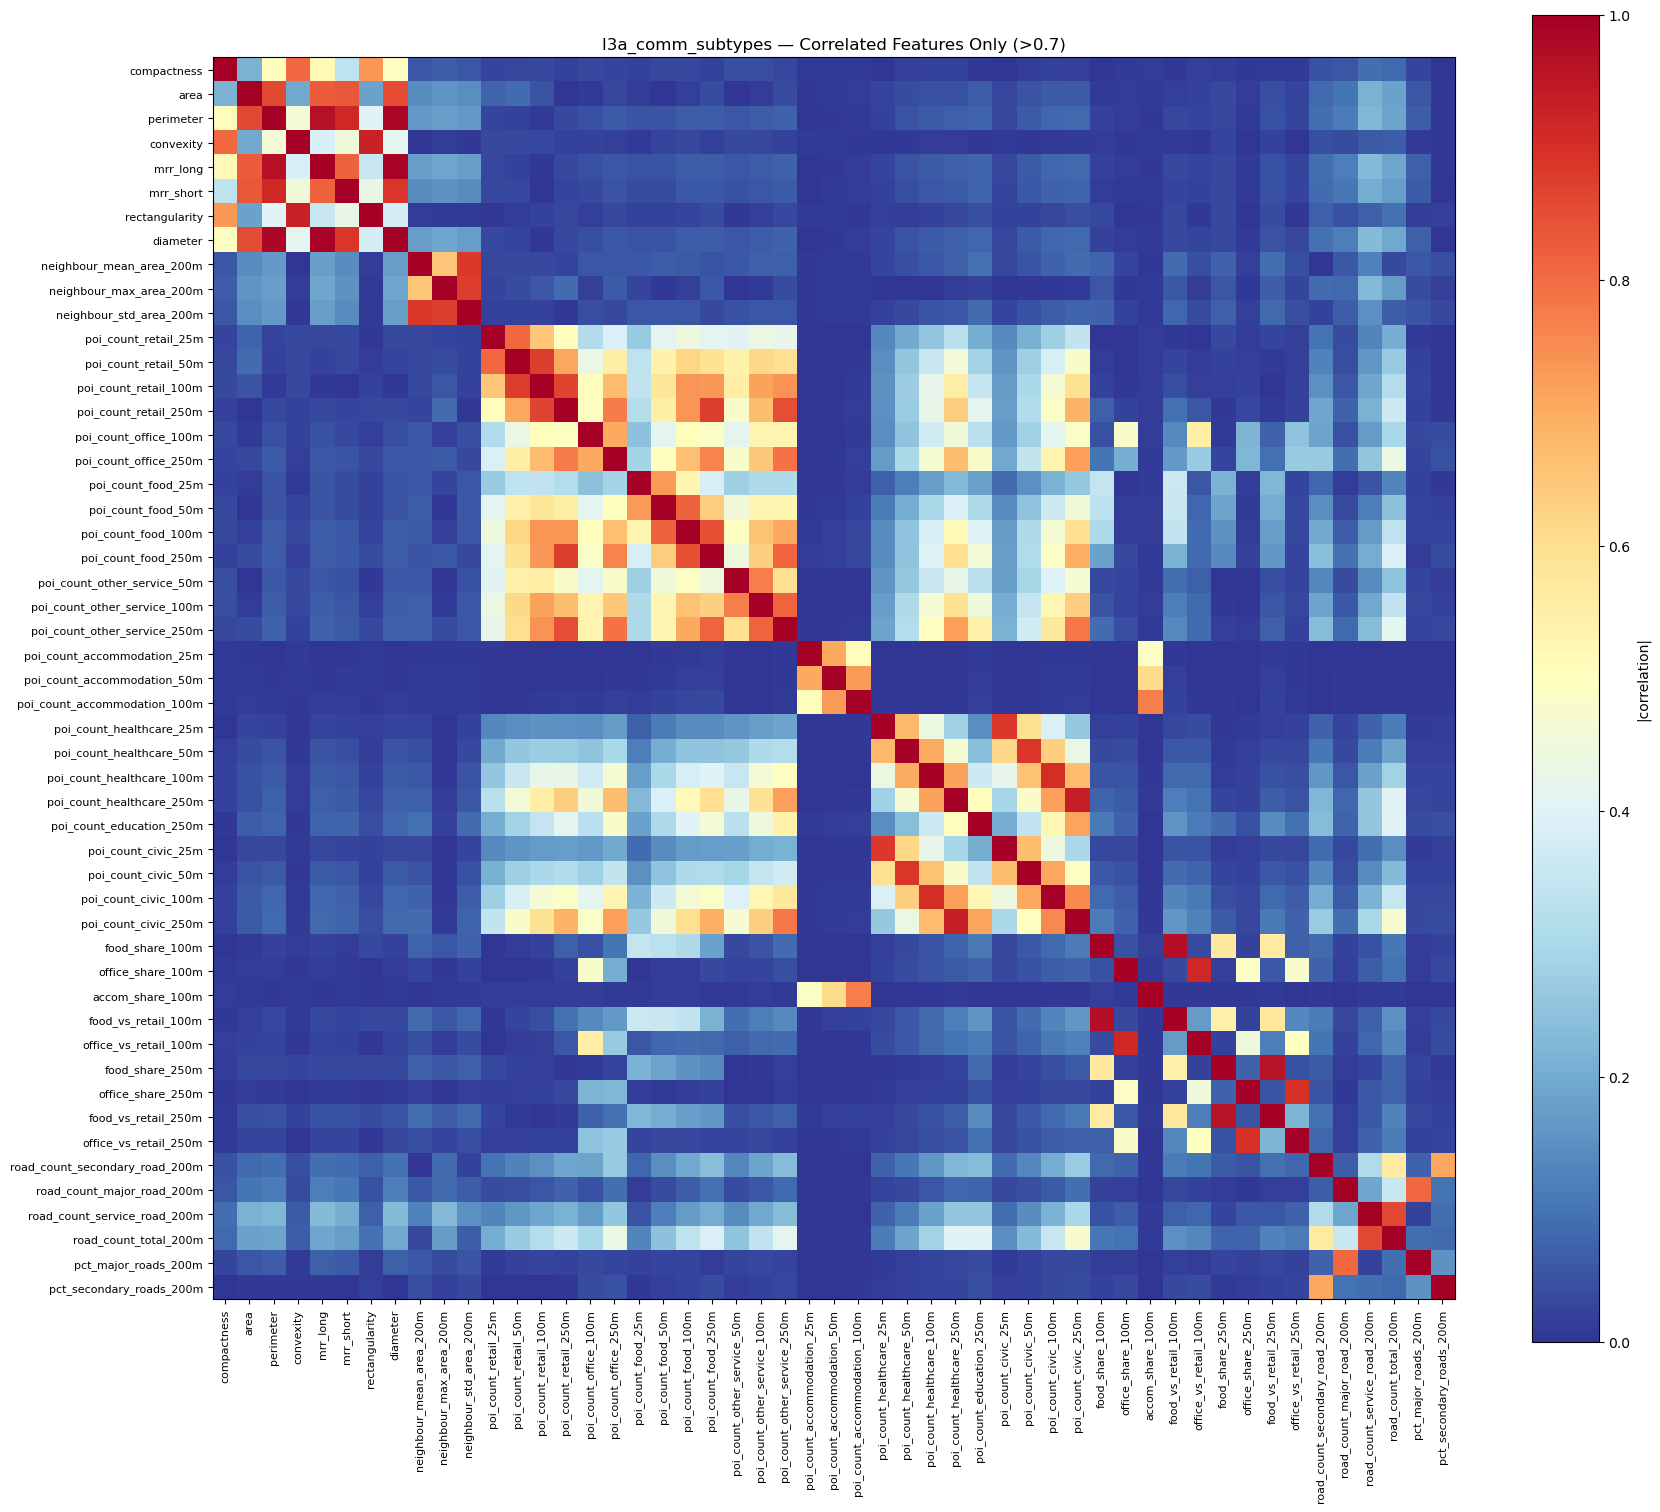

In [4]:
# too many features to view, only show features with correlation above a certain threshold
# check whicc class correspond sto posl_label 0 and 1
print("\nClass labels and their corresponding class names:")
for idx, class_name in enumerate(classes):
    print(f"Class {idx}: {class_name}")
    
FILTER_THRESHOLD = 0.7 


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.9 with all other features):
['address_tier', 'compactness', 'area', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'neighbour_mean_area_200m', 'neighbour_max_area_200m', 'neighbour_std_area_200m', 'poi_count_retail_25m', 'poi_count_retail_50m', 'poi_count_retail_100m', 'poi_count_retail_250m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_office_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_other_service_100m', 'poi_count_other_service_250m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_100m', 'poi_coun

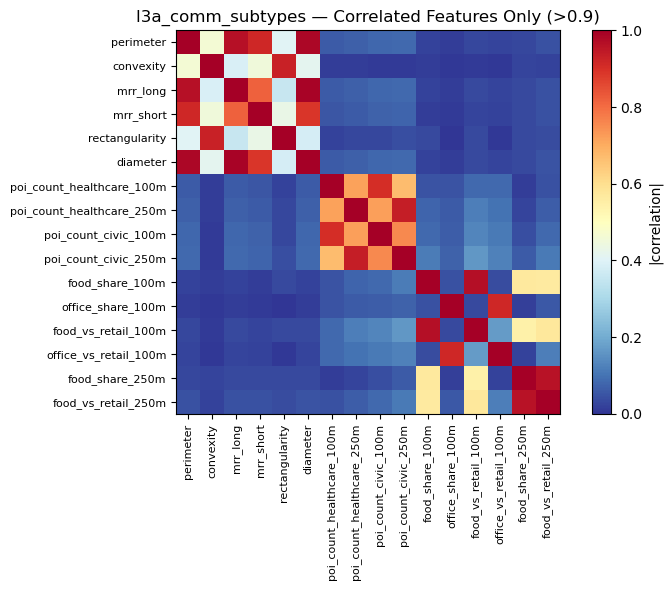

In [5]:

FILTER_THRESHOLD = 0.9  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

In [6]:
# Ranked List of Correlated Pairs

CORR_THRESHOLD = 0.90  # just for flagging — nothing gets dropped in this cell

pairs = []
for i, c1 in enumerate(candidate_features):
    for c2 in candidate_features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if r > CORR_THRESHOLD:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f"{len(pairs_df)} pairs above {CORR_THRESHOLD}:\n")
pairs_df

10 pairs above 0.9:



,feature_1,feature_2,abs_corr
4,mrr_long,diameter,0.990
2,perimeter,diameter,0.983
7,food_share_100m,food_vs_retail_100m,0.968
0,perimeter,mrr_long,0.962
9,food_share_250m,food_vs_retail_250m,0.959
6,poi_count_healthcare_250m,poi_count_civic_250m,0.937
3,convexity,rectangularity,0.929
1,perimeter,mrr_short,0.915
8,office_share_100m,office_vs_retail_100m,0.915
5,poi_count_healthcare_100m,poi_count_civic_100m,0.903


In [7]:
CORR_DROP = ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m',
'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'convexity',
'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building'
]

kept_after_corr = [c for c in candidate_features if c not in CORR_DROP]
print(f"Dropped {len(CORR_DROP)} by hand: {CORR_DROP}")
print(f"Remaining: {len(kept_after_corr)} / {len(candidate_features)}")

Dropped 11 by hand: ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'convexity', 'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building']
Remaining: 102 / 110


Training until validation scores don't improve for 100 rounds
[500]	train's multi_logloss: 0.69701	val's multi_logloss: 0.793163
[1000]	train's multi_logloss: 0.612057	val's multi_logloss: 0.778486
[1500]	train's multi_logloss: 0.544672	val's multi_logloss: 0.769573
[2000]	train's multi_logloss: 0.487871	val's multi_logloss: 0.76422
[2500]	train's multi_logloss: 0.438882	val's multi_logloss: 0.761553
Did not meet early stopping. Best iteration is:
[2500]	train's multi_logloss: 0.438882	val's multi_logloss: 0.761553

BASELINE VAL PERFORMANCE — l3a_comm_subtypes  (102 features)
Macro F1    : 0.5800
Weighted F1 : 0.6747

               precision    recall  f1-score   support

accommodation     0.6302    0.4409    0.5188      1581
   food_drink     0.5081    0.3246    0.3961      1639
       office     0.6640    0.5620    0.6088      2694
       retail     0.7286    0.8774    0.7961      7252

     accuracy                         0.6916     13166
    macro avg     0.6327    0.5512    0.58

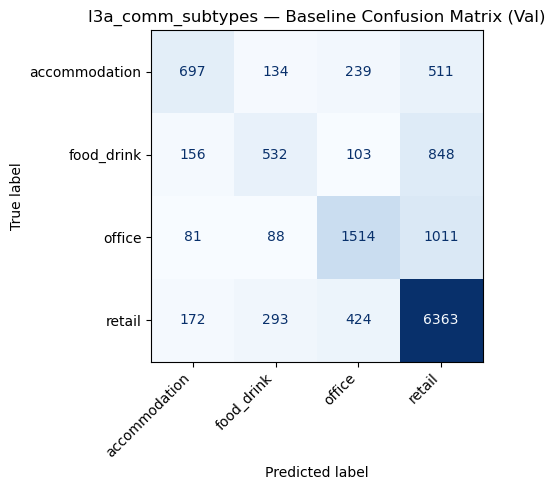

In [8]:
baseline_params = dict(
    n_estimators=2500, learning_rate=0.05, n_jobs=-1,
    random_state=42, verbosity=-1, importance_type='gain'
)
if n_classes == 2:
    lgb_baseline = lgb.LGBMClassifier(objective='binary', eval_metric='binary_logloss', **baseline_params)
else:
    lgb_baseline = lgb.LGBMClassifier(objective='multiclass', num_class=n_classes, eval_metric='multi_logloss', **baseline_params)

baseline_model = lgb_baseline

lgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=500),   
    ]
)
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

y_val_pred = baseline_model.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
baseline_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {baseline_macro_f1:.4f}")
print(f"Weighted F1 : {baseline_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

# Confusion matrix — worth seeing now, before any pruning, as your reference point
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


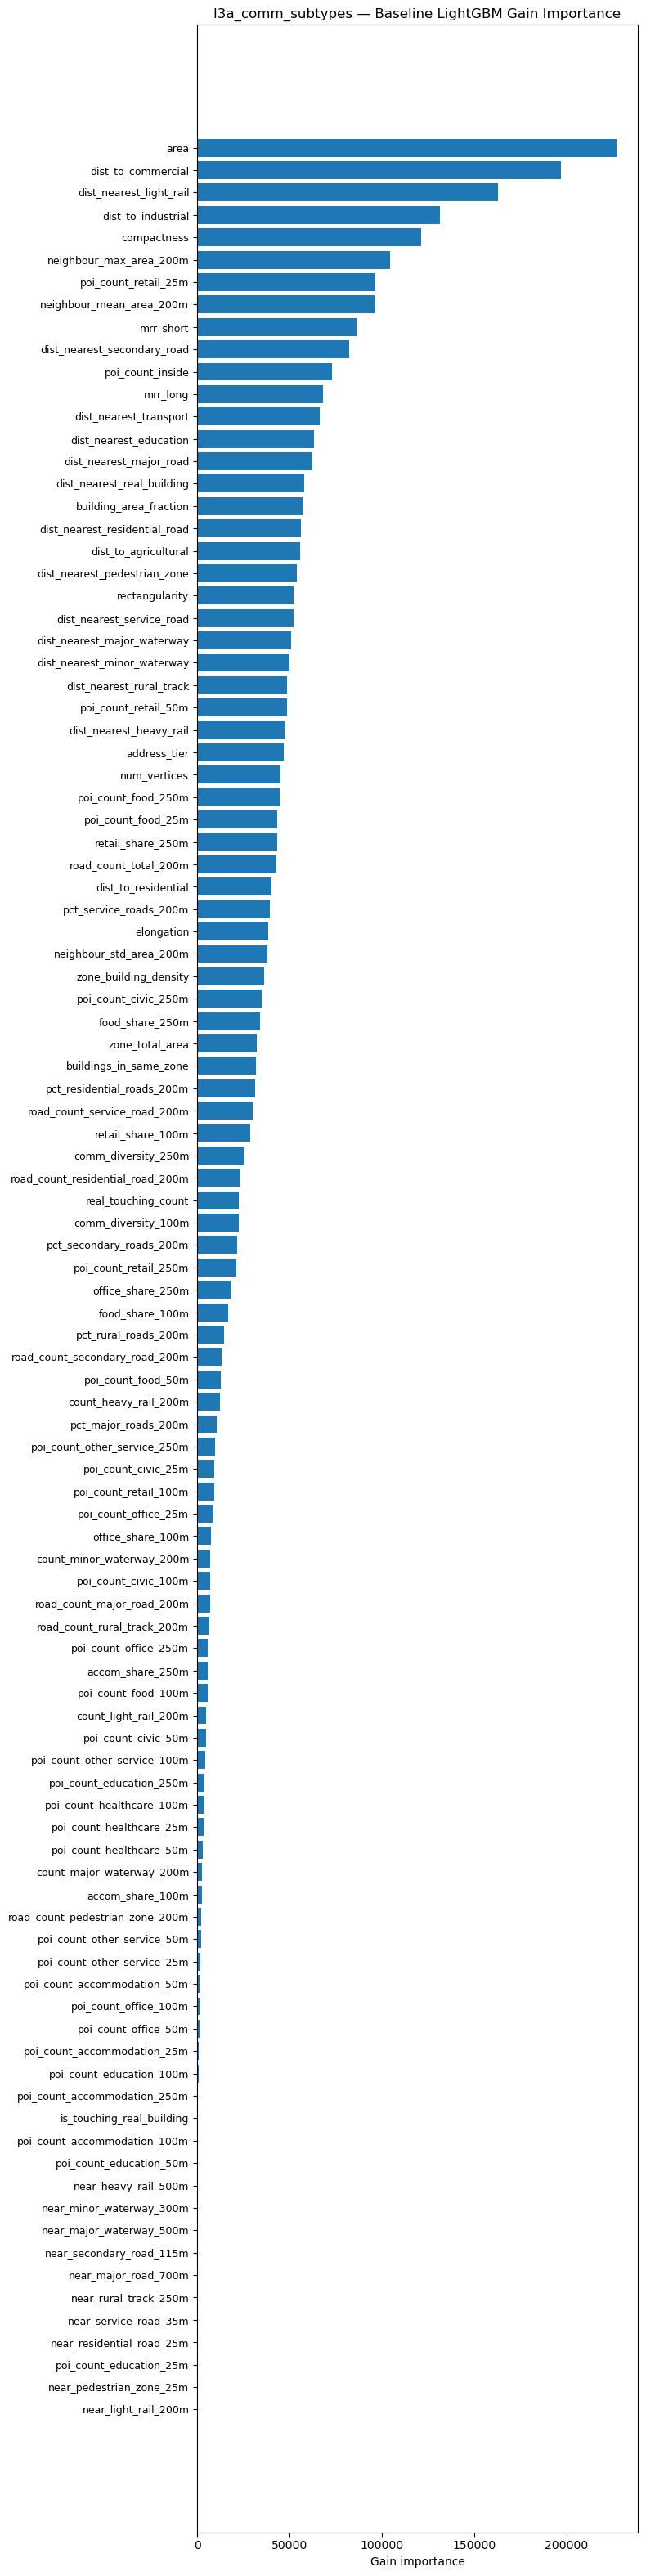

In [9]:
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(kept_after_corr)*0.3 + 1))
ax.barh(range(len(gain_importance)), gain_importance.values[::-1])
ax.set_yticks(range(len(gain_importance)))
ax.set_yticklabels(gain_importance.index[::-1], fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title(f'{LEVEL} — Baseline LightGBM Gain Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-mlogloss:1.14843	validation_1-mlogloss:1.15172
[500]	validation_0-mlogloss:0.71600	validation_1-mlogloss:0.80059
[1000]	validation_0-mlogloss:0.64355	validation_1-mlogloss:0.78407
[1500]	validation_0-mlogloss:0.58178	validation_1-mlogloss:0.77470
[2000]	validation_0-mlogloss:0.52808	validation_1-mlogloss:0.76805
[2499]	validation_0-mlogloss:0.47982	validation_1-mlogloss:0.76402

Stopped at iteration: 2498

BASELINE VAL PERFORMANCE — l3a_comm_subtypes  (102 features)
Macro F1    : 0.5770
Weighted F1 : 0.6719

               precision    recall  f1-score   support

accommodation     0.6283    0.4415    0.5186      1581
   food_drink     0.4913    0.3270    0.3927      1639
       office     0.6567    0.5561    0.6022      2694
       retail     0.7289    0.8727    0.7944      7252

     accuracy                         0.6882     13166
    macro avg     0.6263    0.5493    0.5770     13166
 weighted avg     0.6725    0.6882    0.6719     13166



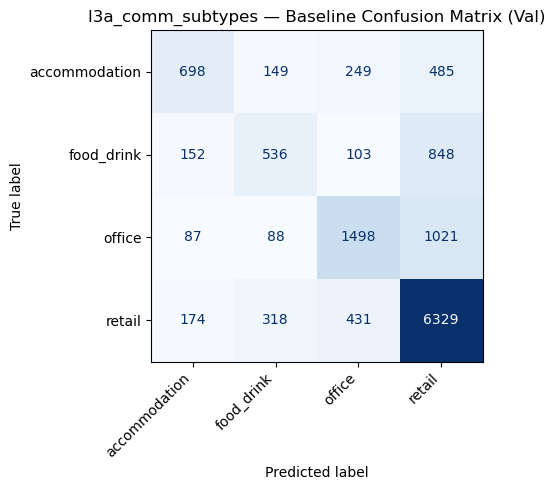

In [10]:
# XGBoost Baseline 
xgb_eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

xgb_params = dict(
    n_estimators=2500,
    learning_rate=0.05,
    n_jobs=-1, random_state=42,
    eval_metric=xgb_eval_metric,
    early_stopping_rounds=50,
)
if n_classes == 2:
    xgb_baseline = xgb.XGBClassifier(objective='binary:logistic', **xgb_params)
else:
    xgb_baseline = xgb.XGBClassifier(objective='multi:softprob', num_class=n_classes, **xgb_params)

xgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    verbose=500   
)

print(f"\nStopped at iteration: {xgb_baseline.best_iteration}")
y_val_pred = xgb_baseline.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
xgb_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
xgb_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {xgb_macro_f1:.4f}")
print(f"Weighted F1 : {xgb_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




In [11]:
# ── XGBoost gain importance — compare ranking against LightGBM's ──
xgb_importance = pd.Series(
    xgb_baseline.get_booster().get_score(importance_type='gain'),
    name='xgb_gain'
)
xgb_importance = xgb_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    'lightgbm_rank': gain_importance.rank(ascending=False),
    'xgboost_rank' : xgb_importance.reindex(gain_importance.index).rank(ascending=False)
}).sort_values('lightgbm_rank')
print("\nTop features — rank agreement between LightGBM and XGBoost:")
comparison.head(20)




Top features — rank agreement between LightGBM and XGBoost:


,lightgbm_rank,xgboost_rank
area,1.0,7.0
dist_to_commercial,2.0,8.0
dist_nearest_light_rail,3.0,4.0
dist_to_industrial,4.0,18.0
compactness,5.0,13.0
neighbour_max_area_200m,6.0,16.0
poi_count_retail_25m,7.0,1.0
neighbour_mean_area_200m,8.0,23.0
mrr_short,9.0,22.0
dist_nearest_secondary_road,10.0,31.0


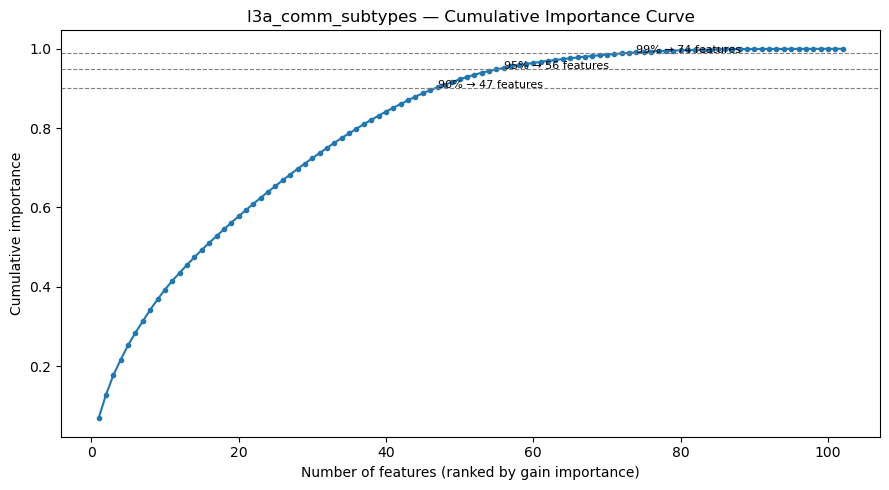

In [12]:
# Cumulative Importance 
cum_importance = gain_importance.cumsum() / gain_importance.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, marker='o', markersize=3)
for pct in [0.90, 0.95, 0.99]:
    ax.axhline(pct, linestyle='--', color='gray', linewidth=0.8)
    n_at_pct = (cum_importance <= pct).sum() + 1
    ax.annotate(f'{int(pct*100)}% → {n_at_pct} features', xy=(n_at_pct, pct), fontsize=8)
ax.set_xlabel('Number of features (ranked by gain importance)')
ax.set_ylabel('Cumulative importance')
ax.set_title(f'{LEVEL} — Cumulative Importance Curve')
plt.tight_layout()
plt.show()

In [13]:
# Reconciling LightGBM vs XGBoost rank disagreement

TOP_N = 74  # adjust based on your elbow plot from Cell H

lgb_top = set(comparison.sort_values('lightgbm_rank').head(TOP_N).index)
xgb_top = set(comparison.sort_values('xgboost_rank').head(TOP_N).index)

both_agree   = lgb_top & xgb_top   # strong keep — both models independently value these
lgb_only     = lgb_top - xgb_top   # LightGBM-favored — likely geometry/distance features
xgb_only     = xgb_top - lgb_top   # XGBoost-favored — likely POI/count features
neither      = set(comparison.index) - lgb_top - xgb_top   # both models agree these are weak

print(f"Both models rank in top {TOP_N}: {len(both_agree)}")
print(sorted(both_agree))
print(f"\nLightGBM-only top {TOP_N} (geometry-leaning?): {len(lgb_only)}")
print(sorted(lgb_only))
print(f"\nXGBoost-only top {TOP_N} (POI-count-leaning?): {len(xgb_only)}")
print(sorted(xgb_only))
print(f"\nBoth models agree these are weak — safe drop candidates: {len(neither)}")
print(sorted(neither))

union_selection = both_agree | lgb_only | xgb_only
selected_features = sorted(union_selection)  # convert to list for indexing
print(f"\nUnion selection: {len(union_selection)} features")

# Before/After Sanity Check


model_full = type(baseline_model)(**baseline_model.get_params())
model_full.fit(X_train[candidate_features], y_train)
pred_full = model_full.predict(X_val[candidate_features])

model_reduced = type(baseline_model)(**baseline_model.get_params())
model_reduced.fit(X_train[selected_features], y_train)
pred_reduced = model_reduced.predict(X_val[selected_features])

avg = 'macro' if n_classes > 2 else 'binary'
f1_full    = f1_score(y_val, pred_full, average=avg)
f1_reduced = f1_score(y_val, pred_reduced, average=avg)

print(f"F1 (val) — full pool ({len(candidate_features)} feats)     : {f1_full:.4f}")
print(f"F1 (val) — selected  ({len(selected_features)} feats)      : {f1_reduced:.4f}")
print(f"Difference: {f1_reduced - f1_full:+.4f}")

Both models rank in top 74: 59
['accom_share_250m', 'address_tier', 'area', 'building_area_fraction', 'buildings_in_same_zone', 'comm_diversity_100m', 'comm_diversity_250m', 'compactness', 'count_heavy_rail_200m', 'dist_nearest_education', 'dist_nearest_heavy_rail', 'dist_nearest_light_rail', 'dist_nearest_major_road', 'dist_nearest_major_waterway', 'dist_nearest_minor_waterway', 'dist_nearest_pedestrian_zone', 'dist_nearest_real_building', 'dist_nearest_residential_road', 'dist_nearest_rural_track', 'dist_nearest_secondary_road', 'dist_nearest_service_road', 'dist_nearest_transport', 'dist_to_agricultural', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_residential', 'food_share_100m', 'food_share_250m', 'mrr_long', 'mrr_short', 'neighbour_max_area_200m', 'neighbour_mean_area_200m', 'neighbour_std_area_200m', 'num_vertices', 'pct_residential_roads_200m', 'pct_service_roads_200m', 'poi_count_civic_100m', 'poi_count_civic_250m', 'poi_count_civic_25m', 'poi_count_civic_50m', 'poi_c

F1 (val) — full pool (110 feats)     : 0.5781
F1 (val) — selected  (89 feats)      : 0.5807
Difference: +0.0026


In [14]:
# Try a more aggressive cut 
for n in [30, 40, 50, 60, 75, 90]:
    trial_features = list(gain_importance.index[:n])
    model_trial = type(baseline_model)(**baseline_model.get_params())
    model_trial.fit(X_train[trial_features], y_train)
    pred_trial = model_trial.predict(X_val[trial_features])
    f1_trial = f1_score(y_val, pred_trial, average='macro' if n_classes > 2 else 'binary')
    print(f"N={n:>3}: F1={f1_trial:.4f}  (diff from full: {f1_trial - f1_full:+.4f})")

N= 30: F1=0.5589  (diff from full: -0.0192)
N= 40: F1=0.5714  (diff from full: -0.0067)
N= 50: F1=0.5733  (diff from full: -0.0048)
N= 60: F1=0.5763  (diff from full: -0.0018)
N= 75: F1=0.5784  (diff from full: +0.0003)
N= 90: F1=0.5806  (diff from full: +0.0025)


In [15]:
joblib.dump(selected_features, os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))

# --- reduce all splits, THEN convert to numpy for XGBoost/LightGBM ---
feature_cols = selected_features   # keeps downstream cells (importance plots) working unchanged
X_train = X_train[selected_features].values
X_val   = X_val[selected_features].values
X_test  = X_test[selected_features].values

In [16]:
def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = model.predict(X_sp).astype(int)
        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        
        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()}")
        print(f"  Macro F1           : {macro_f1:.4f}")
        print(f"  Weighted F1        : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test 
    y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results

all_results = {}


In [17]:
# Multi-Objective Optuna — Setup
n_classes = len(classes)
minority_class_idx = pd.Series(y_train).value_counts().idxmin()
print(f"Minority class: {classes[minority_class_idx]} (index {minority_class_idx})")
print(f"Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)")

def get_sample_weights(y, minority_boost=1.0):
    base_weights = compute_sample_weight(class_weight='balanced', y=y)
    class_counts_local = pd.Series(y).value_counts()
    minority_idx = class_counts_local.idxmin()
    boost_mask = (y == minority_idx)
    weights = base_weights.copy()
    weights[boost_mask] *= minority_boost
    return weights

Minority class: accommodation (index 0)
Optimizing 2 objectives: macro F1 (overall balance) vs minority-class F1 (specific priority)


In [18]:
N_TRIALS  = 50
n_classes = len(classes)


# Compute once outside objectives — same weights reused across trials
# Single split against X_val — CV runs separately in run_final_cv_audit

print(f"Running Optuna across {N_TRIALS} trials...")

def objective_lightgbm(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights = get_sample_weights(y_train, minority_boost=minority_boost)

    params = {
        'objective'        : 'multiclass',
        'num_class'        : n_classes,
        'metric'           : 'multi_logloss',
        'boosting_type'    : 'gbdt',
        'n_estimators'     : 2000,
        'learning_rate'    : trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'max_depth'        : -1,
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 300),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        #'device'           : 'gpu',
        'n_jobs'           : -1,
        'random_state'     : 42,
        'verbosity'        : -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1 = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]

    # Store the full breakdown so you can inspect any trial later without retraining
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1


def objective_xgboost(trial):
    minority_boost = trial.suggest_float('minority_boost', 1.0, 5.0)
    sample_weights = get_sample_weights(y_train, minority_boost=minority_boost)

    params = {
        'objective'            : 'multi:softprob',
        'num_class'            : n_classes,
        'eval_metric'          : 'mlogloss',
        'n_estimators'         : 2000,
        'learning_rate'        : trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'max_depth'            : trial.suggest_int('max_depth', 4, 10),
        'subsample'            : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'     : trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'alpha'                : trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda'               : trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'gamma'                : trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        'min_child_weight'     : trial.suggest_int('min_child_weight', 1, 60, log=True),
        'tree_method'          : 'hist',
        'device'               : 'cuda',
        'early_stopping_rounds': 30,
        'n_jobs'               : -1,
        'random_state'         : 42
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict(X_val)
    f1_per_class = f1_score(y_val, preds, average=None)

    macro_f1 = f1_per_class.mean()
    minority_f1 = f1_per_class[minority_class_idx]
    
    # Store the full breakdown so you can inspect any trial later without retraining
    trial.set_user_attr('f1_per_class', f1_per_class.tolist())

    return macro_f1, minority_f1


# Run Multi-Objective Optimization

print("Optimizing LightGBM (multi-objective)...")
study_lgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_lgb_multi.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\nLightGBM Pareto front: {len(study_lgb_multi.best_trials)} non-dominated trials")

print("\nOptimizing XGBoost (multi-objective)...")
study_xgb_multi = optuna.create_study(directions=['maximize', 'maximize'])
study_xgb_multi.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)
print(f"XGBoost Pareto front : {len(study_xgb_multi.best_trials)} non-dominated trials")


Running Optuna across 50 trials...
Optimizing LightGBM (multi-objective)...


  0%|                                                                                                                                                                                                                                                                                              | 0/50 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [6:27:55<00:00, 465.50s/it]



LightGBM Pareto front: 1 non-dominated trials

Optimizing XGBoost (multi-objective)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [1:52:34<00:00, 135.08s/it]

XGBoost Pareto front : 2 non-dominated trials


Number of trials on the Pareto front: 1
Trial with highest accuracy: 
	number: 29
	params: {'minority_boost': 1.0641787693007352, 'learning_rate': 0.0641494399631944, 'num_leaves': 123, 'min_child_samples': 297, 'subsample': 0.6221786605328554, 'colsample_bytree': 0.5614522896420875, 'reg_alpha': 1.2576332057238964, 'reg_lambda': 0.0012479218862622272}
	values: [0.6180092684902643, 0.5795601552393272]
Number of trials on the Pareto front: 2
Trial with highest accuracy: 
	number: 3
	params: {'minority_boost': 4.00277488545035, 'learning_rate': 0.10476349921421853, 'max_depth': 8, 'subsample': 0.7108757967164997, 'colsample_bytree': 0.6178624408763592, 'alpha': 0.39511551018548574, 'lambda': 3.7999114265823315, 'gamma': 0.007884538984224995, 'min_child_weight': 17}
	values: [0.6073900935926585, 0.576092971776425]
Minority F1 values across all trials:
count    50.000000
mean      0.535101
std       0.028384
min       0.460977
25%       0.511269
50%       0.540509
75%       0.556678
max   

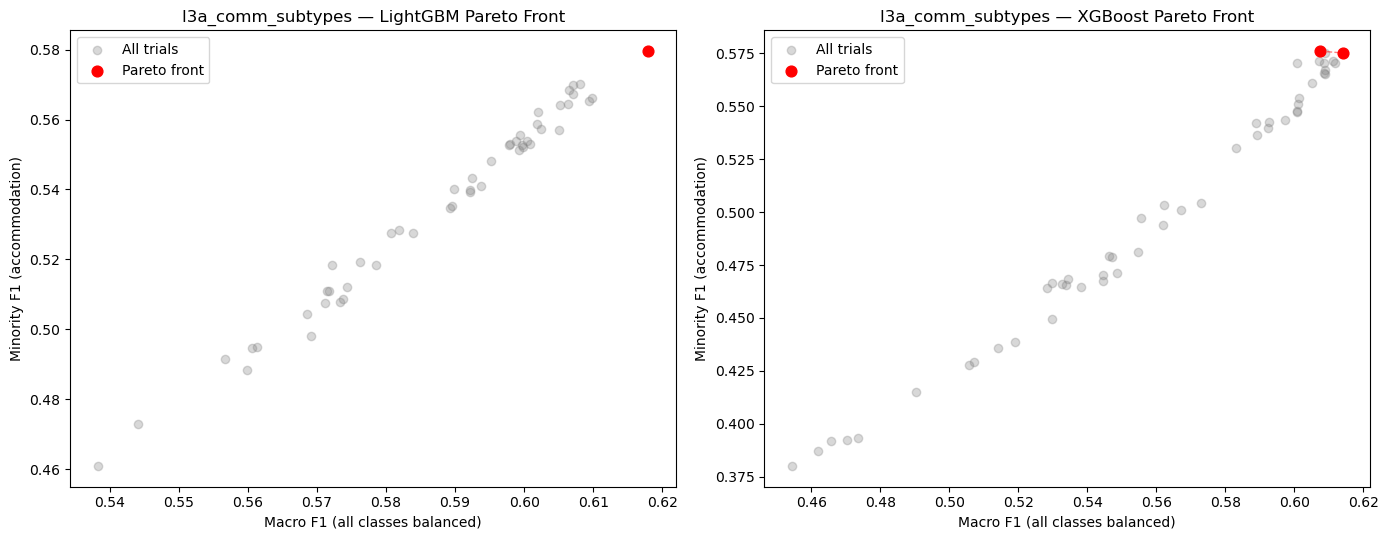

In [19]:
print(f"Number of trials on the Pareto front: {len(study_lgb_multi.best_trials)}")

trial_with_highest_score_lgb = max(study_lgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_lgb.number}")
print(f"\tparams: {trial_with_highest_score_lgb.params}")
print(f"\tvalues: {trial_with_highest_score_lgb.values}")

print(f"Number of trials on the Pareto front: {len(study_xgb_multi.best_trials)}")

trial_with_highest_score_xgb = max(study_xgb_multi.best_trials, key=lambda t: t.values[1])
print("Trial with highest accuracy: ")
print(f"\tnumber: {trial_with_highest_score_xgb.number}")
print(f"\tparams: {trial_with_highest_score_xgb.params}")
print(f"\tvalues: {trial_with_highest_score_xgb.values}")

# Check which of the three explanations applies
print("Minority F1 values across all trials:")
minority_f1_values = [t.values[1] for t in study_lgb_multi.trials if t.values is not None]
print(pd.Series(minority_f1_values).describe())
print(f"\nUnique minority-F1 values: {len(set(round(v, 4) for v in minority_f1_values))}")

print("\nminority_boost values tried:")
boosts = [t.params['minority_boost'] for t in study_lgb_multi.trials]
print(pd.Series(boosts).describe())

# Check which of the three explanations applies
print("Minority F1 values across all trials:")
minority_f1_values_xgb = [t.values[1] for t in study_xgb_multi.trials if t.values is not None]
print(pd.Series(minority_f1_values_xgb).describe())
print(f"\nUnique minority-F1 values: {len(set(round(v, 4) for v in minority_f1_values_xgb))}")

print("\nminority_boost values tried:")
boosts_xgb = [t.params['minority_boost'] for t in study_xgb_multi.trials]
print(pd.Series(boosts_xgb).describe())

# Plot the Pareto Front
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, study, name in [(axes[0], study_lgb_multi, 'LightGBM'), (axes[1], study_xgb_multi, 'XGBoost')]:
    all_macro    = [t.values[0] for t in study.trials if t.values is not None]
    all_minority = [t.values[1] for t in study.trials if t.values is not None]
    pareto_macro    = [t.values[0] for t in study.best_trials]
    pareto_minority = [t.values[1] for t in study.best_trials]

    ax.scatter(all_macro, all_minority, alpha=0.3, color='gray', label='All trials')
    ax.scatter(pareto_macro, pareto_minority, color='red', s=60, label='Pareto front', zorder=5)

    # Sort pareto points to draw a connecting line
    pareto_pts = sorted(zip(pareto_macro, pareto_minority))
    ax.plot(*zip(*pareto_pts), color='red', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_xlabel('Macro F1 (all classes balanced)')
    ax.set_ylabel(f'Minority F1 ({classes[minority_class_idx]})')
    ax.set_title(f'{LEVEL} — {name} Pareto Front')
    ax.legend()

plt.tight_layout()
plt.show()

In [20]:
# Select a trial from the Pareto front 
# Rule: maximize minority F1, subject to macro F1 not dropping more than
# MAX_MACRO_DROP below the single best macro-F1 trial on the front.
MAX_MACRO_DROP = 0.01

best_macro_on_front = max(t.values[0] for t in study_lgb_multi.best_trials)
eligible_trials = [
    t for t in study_lgb_multi.best_trials
    if t.values[0] >= best_macro_on_front - MAX_MACRO_DROP
]
selected_trial = max(eligible_trials, key=lambda t: t.values[1])  # highest minority F1 among eligible

print(f"Selected trial #{selected_trial.number}")
print(f"  Macro F1    : {selected_trial.values[0]:.4f}  (best on front: {best_macro_on_front:.4f})")
print(f"  Minority F1 : {selected_trial.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial.params}")

best_lgb_params = selected_trial.params


# Select a trial from the XGBoost Pareto front — same rule as LightGBM
best_macro_on_front_xgb = max(t.values[0] for t in study_xgb_multi.best_trials)
eligible_trials_xgb = [
    t for t in study_xgb_multi.best_trials
    if t.values[0] >= best_macro_on_front_xgb - MAX_MACRO_DROP
]
selected_trial_xgb = max(eligible_trials_xgb, key=lambda t: t.values[1])

print(f"Selected XGBoost trial #{selected_trial_xgb.number}")
print(f"  Macro F1    : {selected_trial_xgb.values[0]:.4f}  (best on front: {best_macro_on_front_xgb:.4f})")
print(f"  Minority F1 : {selected_trial_xgb.values[1]:.4f}")
print(f"  Per-class F1: {dict(zip(classes, selected_trial_xgb.user_attrs['f1_per_class']))}")
print(f"  Params      : {selected_trial_xgb.params}")

best_xgb_params = selected_trial_xgb.params

Selected trial #29
  Macro F1    : 0.6180  (best on front: 0.6180)
  Minority F1 : 0.5796
  Per-class F1: {'accommodation': 0.5795601552393272, 'food_drink': 0.4640760413754543, 'office': 0.6377392889699179, 'retail': 0.7906615883763577}
  Params      : {'minority_boost': 1.0641787693007352, 'learning_rate': 0.0641494399631944, 'num_leaves': 123, 'min_child_samples': 297, 'subsample': 0.6221786605328554, 'colsample_bytree': 0.5614522896420875, 'reg_alpha': 1.2576332057238964, 'reg_lambda': 0.0012479218862622272}
Selected XGBoost trial #3
  Macro F1    : 0.6074  (best on front: 0.6140)
  Minority F1 : 0.5761
  Per-class F1: {'accommodation': 0.576092971776425, 'food_drink': 0.44016587677725116, 'office': 0.6307177389364076, 'retail': 0.78258378688055}
  Params      : {'minority_boost': 4.00277488545035, 'learning_rate': 0.10476349921421853, 'max_depth': 8, 'subsample': 0.7108757967164997, 'colsample_bytree': 0.6178624408763592, 'alpha': 0.39511551018548574, 'lambda': 3.7999114265823315,

In [21]:
# Train Final Model with Selected Pareto-Front Params
final_minority_boost_lgb = best_lgb_params.pop('minority_boost', None)  # not a model param, remove before passing to LGBMClassifier
if final_minority_boost_lgb is None:
    raise ValueError("Selected LightGBM trial does not have 'minority_boost' parameter.")
final_sample_weights_lgb = get_sample_weights(y_train, minority_boost=final_minority_boost_lgb)

final_minority_boost_xgb = best_xgb_params.pop('minority_boost', None)  # not a model param
if final_minority_boost_xgb is None:
    raise ValueError("Selected XGBoost trial does not have 'minority_boost' parameter.")
final_sample_weights_xgb = get_sample_weights(y_train, minority_boost=final_minority_boost_xgb)

# save the best hyperparameters for reference
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'w') as f:
    json.dump({'lightgbm': best_lgb_params, 'xgboost': best_xgb_params}, f, indent=4)


In [22]:
print(f"\n{'='*60}\nTRAINING UNIFIED MODELS ON FULL X_TRAIN\n{'='*60}")
trained_models = {}

# --- Train LightGBM ---
print("Training unified LightGBM...")
lgb_params = {
    'objective': 'multiclass', 'num_class': n_classes, 'metric': 'multi_logloss', 
    'boosting_type': 'gbdt', 'n_estimators': 15000, 
    'importance_type': 'gain', 'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    **best_lgb_params
}
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(
    X_train, y_train,
    sample_weight=final_sample_weights_lgb,   
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
save_path_lgb = os.path.join(MODEL_DIR, f'{LEVEL}_lightgbm_optimized.pkl')
joblib.dump(model_lgb, save_path_lgb)
trained_models['lightgbm'] = model_lgb

# --- Train XGBoost ---
print("Training unified XGBoost...")
xgb_params = {
    'objective': 'multi:softprob', 'num_class': n_classes, 'eval_metric': 'mlogloss',
    'n_estimators': 15000, 'tree_method': 'hist', 'device': 'cuda', 'importance_type': 'gain',
    'early_stopping_rounds': 100, 'n_jobs': -1, 'random_state': 42,
    **best_xgb_params
}
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(
    X_train, y_train,
    sample_weight=final_sample_weights_xgb,
    eval_set=[(X_val, y_val)],
    verbose=False
)
save_path_xgb = os.path.join(MODEL_DIR, f'{LEVEL}_xgboost_optimized.pkl')
joblib.dump(model_xgb, save_path_xgb)
trained_models['xgboost'] = model_xgb

print("\nUnified base models trained and stored in `trained_models`!")


TRAINING UNIFIED MODELS ON FULL X_TRAIN
Training unified LightGBM...
[200]	valid_0's multi_logloss: 0.892512
[400]	valid_0's multi_logloss: 0.853911
[600]	valid_0's multi_logloss: 0.827568
[800]	valid_0's multi_logloss: 0.808601
[1000]	valid_0's multi_logloss: 0.794848
[1200]	valid_0's multi_logloss: 0.785188
[1400]	valid_0's multi_logloss: 0.778448
[1600]	valid_0's multi_logloss: 0.774288
[1800]	valid_0's multi_logloss: 0.77168
[2000]	valid_0's multi_logloss: 0.770612
Training unified XGBoost...

Unified base models trained and stored in `trained_models`!



FINAL HOLDOUT TEST SET EVALUATION

lightgbm — VAL
  Macro F1           : 0.6195
  Weighted F1        : 0.6951
               precision    recall  f1-score   support

accommodation     0.6027    0.5642    0.5828      1581
   food_drink     0.4295    0.5003    0.4622      1639
       office     0.6300    0.6511    0.6404      2694
       retail     0.8072    0.7784    0.7926      7252

     accuracy                         0.6920     13166
    macro avg     0.6174    0.6235    0.6195     13166
 weighted avg     0.6994    0.6920    0.6951     13166


lightgbm — TEST
  Macro F1           : 0.6275
  Weighted F1        : 0.7026
               precision    recall  f1-score   support

accommodation     0.6073    0.5682    0.5871      3029
   food_drink     0.4424    0.4959    0.4676      3315
       office     0.6433    0.6748    0.6587      5366
       retail     0.8100    0.7838    0.7967     14495

     accuracy                         0.7001     26205
    macro avg     0.6257    0.6307   

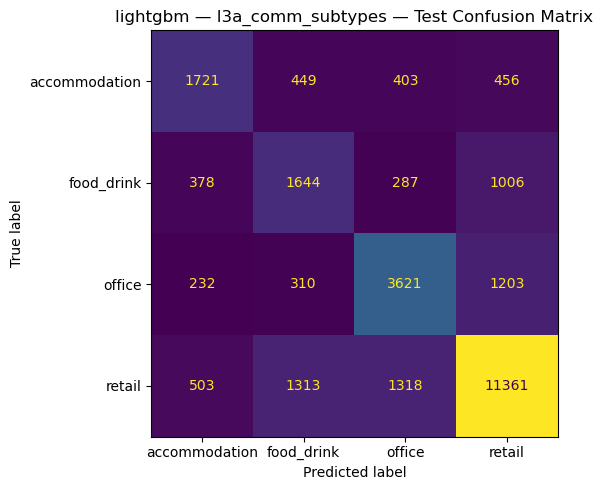


xgboost — VAL
  Macro F1           : 0.6116
  Weighted F1        : 0.6887
               precision    recall  f1-score   support

accommodation     0.5295    0.6471    0.5824      1581
   food_drink     0.4367    0.4503    0.4434      1639
       office     0.6370    0.6281    0.6325      2694
       retail     0.8091    0.7685    0.7883      7252

     accuracy                         0.6856     13166
    macro avg     0.6031    0.6235    0.6116     13166
 weighted avg     0.6940    0.6856    0.6887     13166


xgboost — TEST
  Macro F1           : 0.6125
  Weighted F1        : 0.6906
               precision    recall  f1-score   support

accommodation     0.5177    0.6434    0.5737      3029
   food_drink     0.4469    0.4401    0.4435      3315
       office     0.6419    0.6463    0.6441      5366
       retail     0.8095    0.7691    0.7888     14495

     accuracy                         0.6878     26205
    macro avg     0.6040    0.6247    0.6125     26205
 weighted avg     0

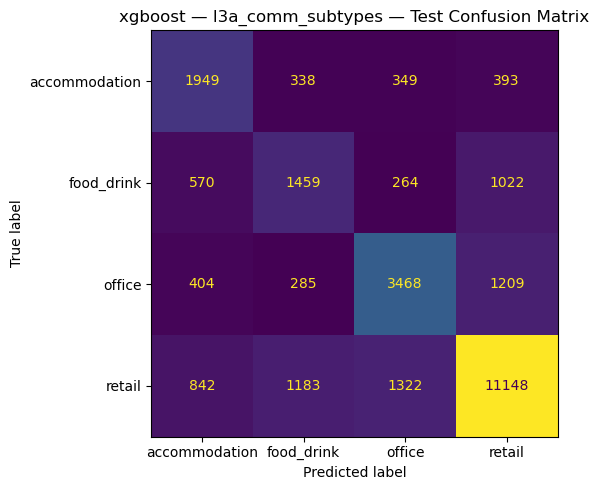


MODEL COMPARISON — l3a_comm_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.6275        0.7026
xgboost                  0.6125        0.6906


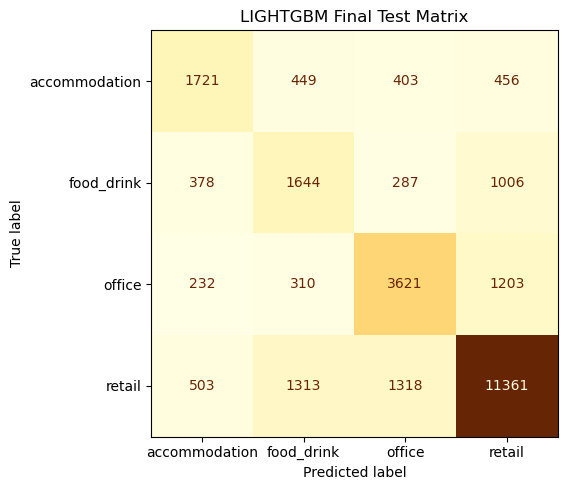

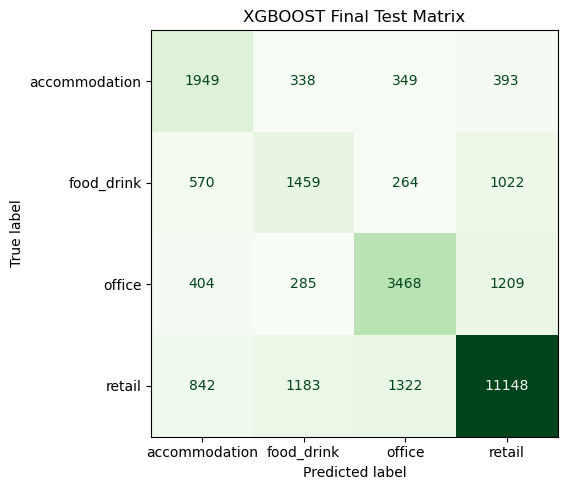

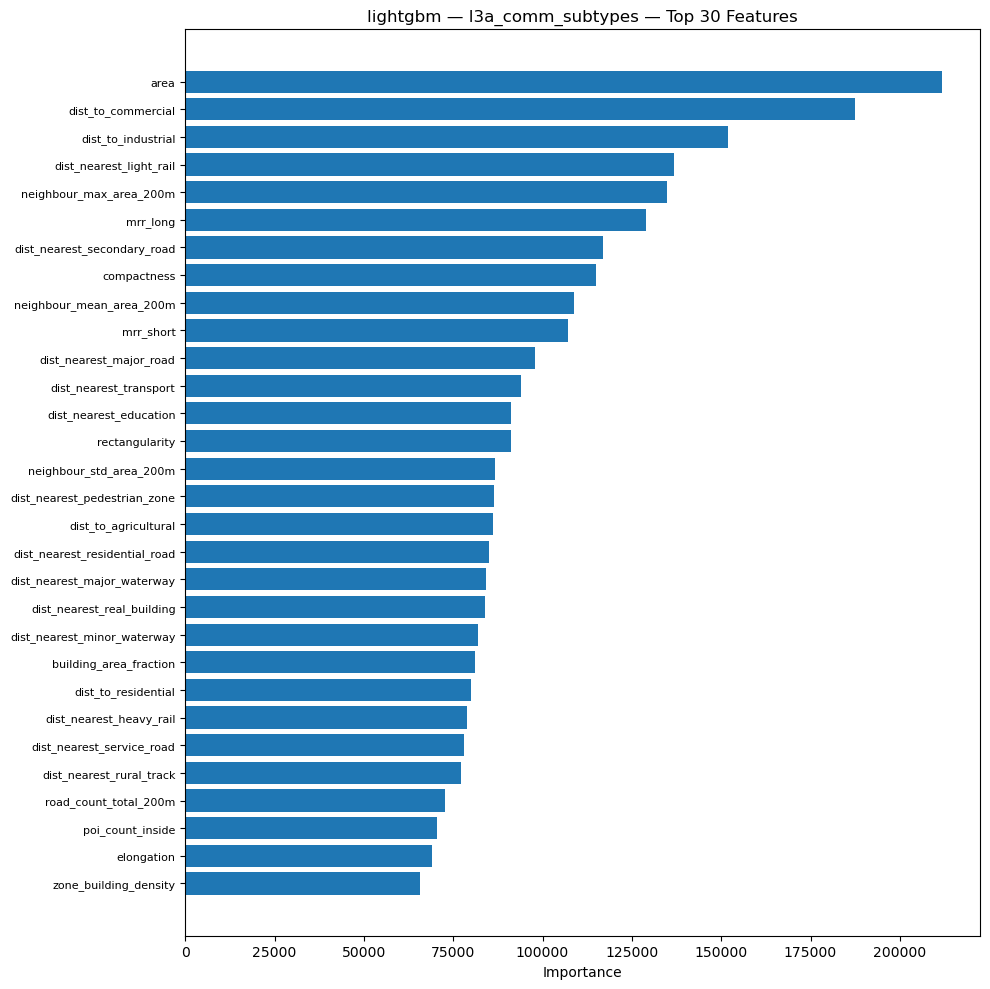

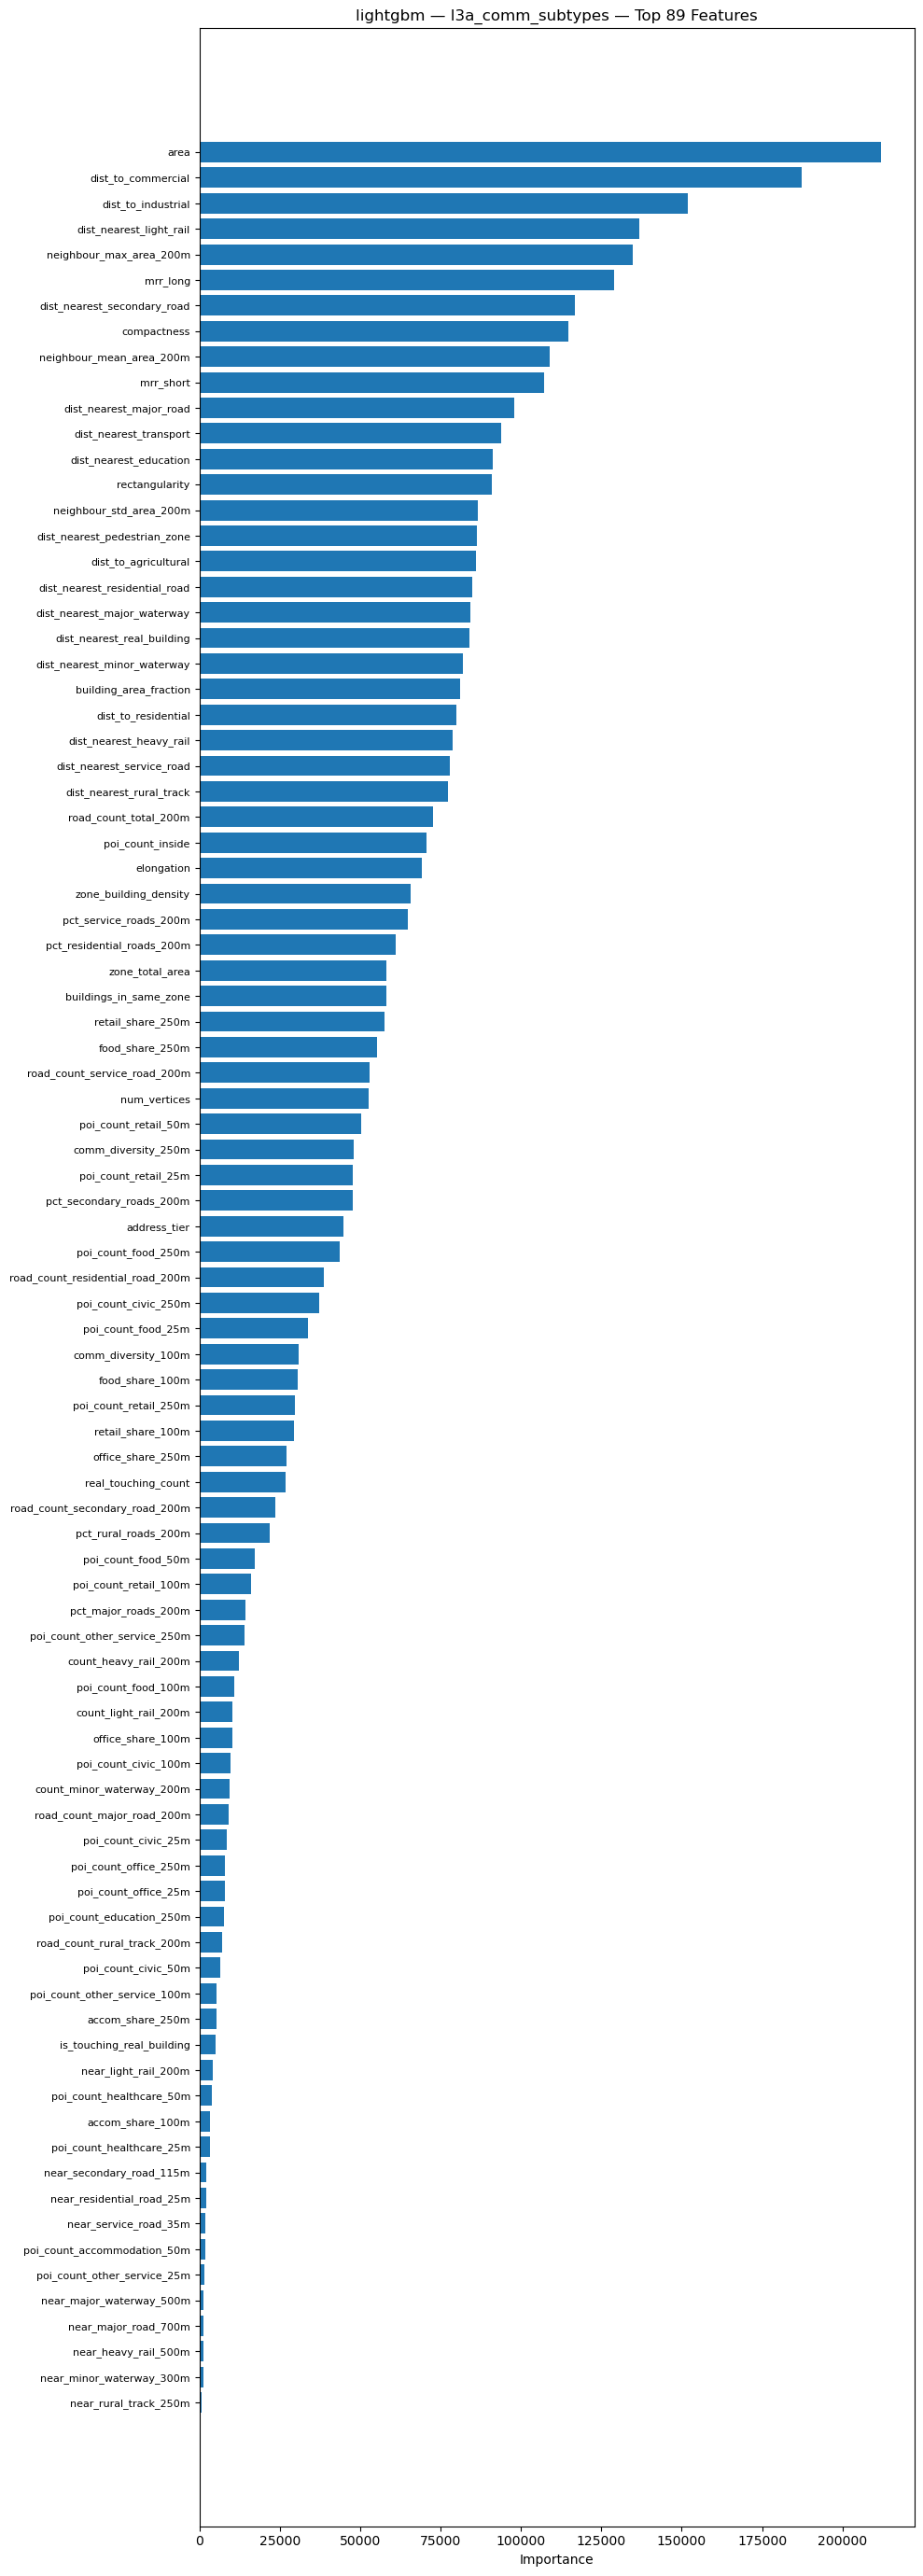

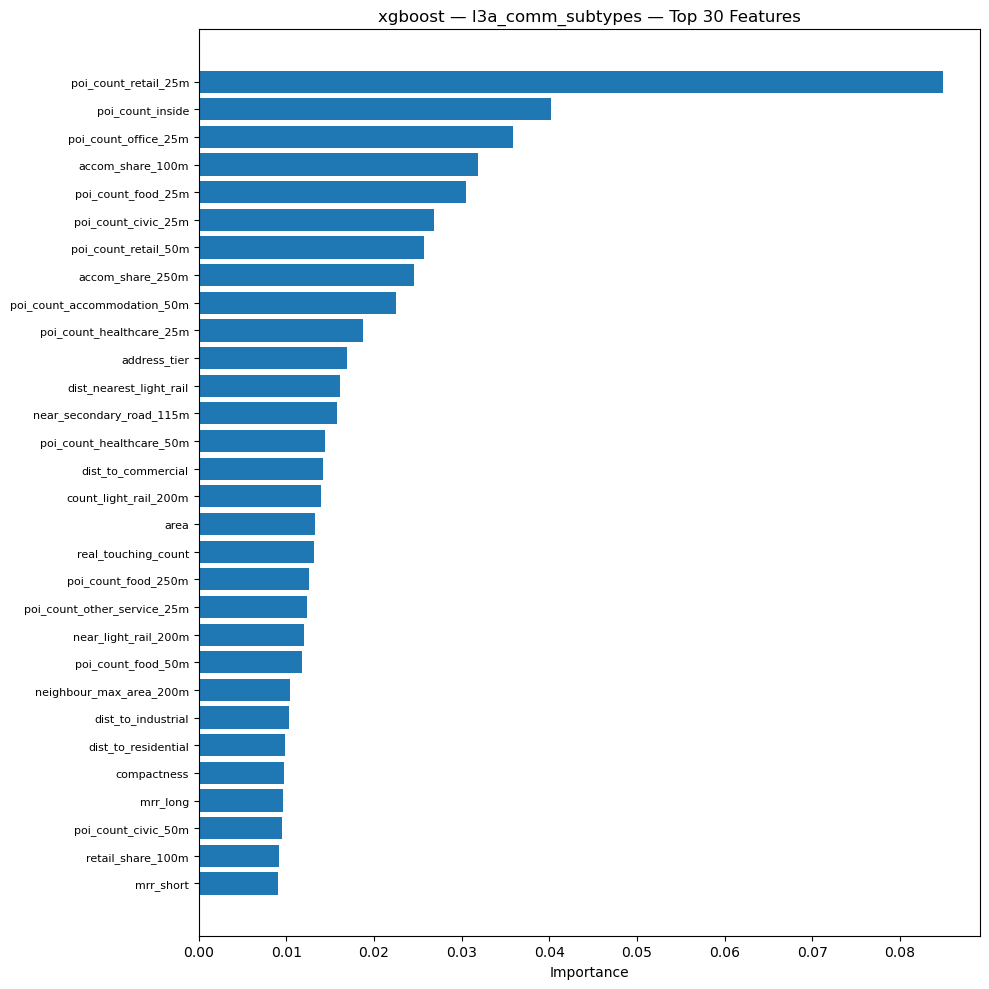

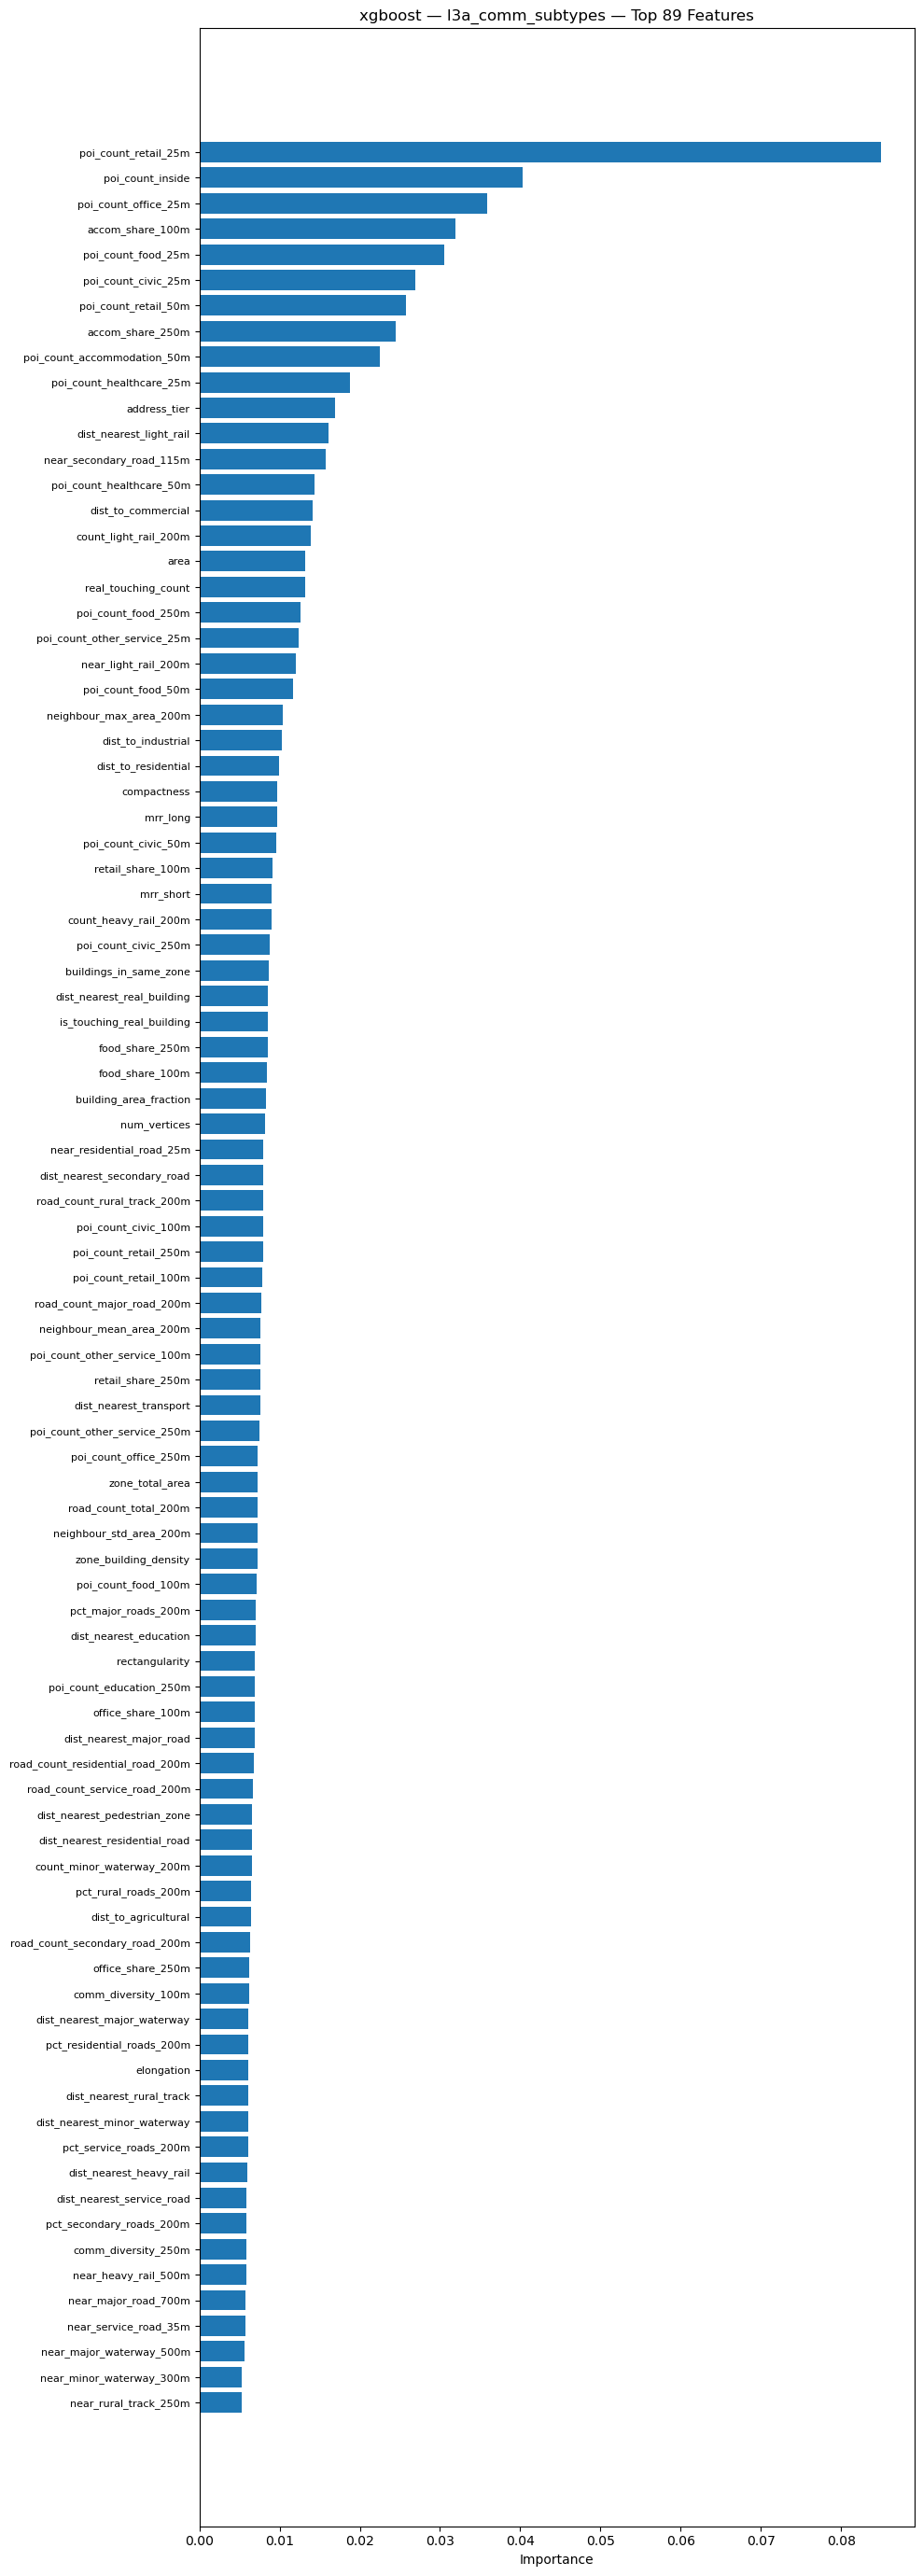

In [23]:
print(f"\n{'='*60}\nFINAL HOLDOUT TEST SET EVALUATION\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL)

print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)
for model_name, res in all_results.items():
    print(f"{model_name:<20} {res['test']['macro_f1']:>10.4f} {res['test']['weighted_f1']:>13.4f}")

# Print Confusion Matrices on Unseen Test Set
for model_name, model in trained_models.items():
    test_preds = model.predict(X_test).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    cmap_color = 'YlOrBr' if model_name == 'lightgbm' else 'Greens'
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap=cmap_color, colorbar=False)
    ax.set_title(f'{model_name.upper()} Final Test Matrix')
    plt.tight_layout()
    plt.show()

# Print Feature Importances
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        idx  = np.argsort(imp)[::-1][:top_n]
        fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
        ax.barh(range(top_n), imp[idx][::-1])
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
        ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [24]:
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l3a_comm_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.6275        0.7026
xgboost                  0.6125        0.6906

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l3a_comm_subtypes_results.json


In [26]:
# FINAL PRODUCTION ROLLOUT 
BEST_MODEL_NAME = 'lightgbm'  # Change to 'xgboost' if XGBoost performed better

print(f"Preparing final production model: {BEST_MODEL_NAME.upper()} on 100% of data")

# Combine ALL data splits (100% of available data)
X_production_train = np.vstack([X_train, X_val, X_test])
y_production_train = np.concatenate([y_train, y_val, y_test])

# Recompute balanced weights on the entire dataset
prod_weights = get_sample_weights(
    y_production_train,
    minority_boost=final_minority_boost_lgb if BEST_MODEL_NAME == 'lightgbm' else final_minority_boost_xgb
)

print(f"100% Production training pool : {X_production_train.shape[0]:,} rows")
print(f"Minority class instances      : {np.bincount(y_production_train)}")

# Extract the optimal tree count from your previously trained Unified Base Model
best_unified_model = trained_models[BEST_MODEL_NAME]

if BEST_MODEL_NAME == 'lightgbm':
    # LightGBM uses 'best_iteration_'
    optimal_trees = best_unified_model.best_iteration_
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(classes), metric='multi_logloss',
        boosting_type='gbdt', 
        n_estimators=production_trees, # HARDCODED EXACT TREE COUNT
        importance_type='gain', n_jobs=-1, random_state=42, verbosity=-1,
        **best_lgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights
    )

elif BEST_MODEL_NAME == 'xgboost':
    # XGBoost uses 'best_iteration'
    optimal_trees = best_unified_model.best_iteration
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss',
        n_estimators=production_trees, importance_type='gain',
        tree_method='hist', device='cuda', n_jobs=-1, random_state=42,
        **best_xgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights,
        verbose=False
    )

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_lgb_PRODUCTION_FINAL.pkl')
joblib.dump(prod_model, production_save_path)
print(f"\n{'='*60}\n✅ ULTIMATE PRODUCTION MODEL DEPLOYED!\n   Saved model to: {production_save_path}\n{'='*60}")

Preparing final production model: LIGHTGBM on 100% of data
100% Production training pool : 263,542 rows
Minority class instances      : [ 30622  32634  55086 145200]
🎯 Optimal trees extracted from unified model: 2101

✅ ULTIMATE PRODUCTION MODEL DEPLOYED!
   Saved model to: /fast/home/o-olajuyigbe/osm_project/data/models/l3a_comm_subtypes_lgb_PRODUCTION_FINAL.pkl
